In [1]:

import matplotlib.pyplot as plt
import os
from matplotlib import cm
from tqdm import tqdm
import os
import numpy as np
from numpy import linalg as la
from numpy import *
from sklearn.model_selection import train_test_split


In [2]:
def ou_process_1d(theta=1, mu=0, sigma=1, X0=0, n_steps=10000, n_eval=200, h=1e-5):
    """
    Simulates the Ornstein-Uhlenbeck process.
    
    Parameters:
    - theta: rate of mean reversion
    - mu: long-term mean of the process
    - sigma: volatility
    - X0: initial value
    - n_steps: number of steps in each evaluation
    - n_eval: number of evaluations
    - h: Integration step size
    
    Returns:
    - A numpy array containing the simulated values at each evaluation
    """
    X_eval = np.zeros(n_eval)
    X = X0
    
    for i in range(n_eval):
        for _ in range(n_steps):
            dW = np.sqrt(h) * np.random.randn()
            X = X + theta * (mu - X) * h + sigma * dW
        X_eval[i] = X
    
    return X_eval

## Setup the parameters
theta = 1
mu = 0
sigma = 0.1

In [3]:
# Generate m initial points from the domain space [-2, 2]
m = 100
n_eval = 1
n_steps = 1000
h = 1e-5
lag_time = n_steps * h
print("lag time: ", lag_time)
X0_values = np.linspace(-2, 2, m)

# Initialize the data_matrix
data_matrix = np.zeros((m, n_eval+1, 1))

# Simulate trajectories for each initial point and store them in the data_matrix
for i, X0 in tqdm(enumerate(X0_values), total=m, desc="Simulating trajectories"):
    X_eval = np.concatenate(([X0], ou_process_1d(X0=X0, n_steps=n_steps, n_eval=n_eval, h=h)))
    data_matrix[i, :, 0] = X_eval

# Print the shape of data_matrix
print("Shape of data_matrix:", data_matrix.shape)

# Extract data_X and data_Y from the data matrix
data_X = data_matrix[:, :-1, :]
data_Y = data_matrix[:, 1:, :]
print(f"Shape of data_X: {data_X.shape}")
print(f"Shape of data_Y: {data_Y.shape}")

# Reshape data_X and data_Y into a single column
X = data_X.reshape(-1, data_X.shape[2])  # 2D features
Y = data_Y.reshape(-1, data_X.shape[2])  # 2D targets
print(f"Shape of X: {X.shape}")
print(f"Shape of Y: {Y.shape}")

# Separate data into two parts: train and validation
len_all = X.shape[0]

print(X.shape)

lag time:  0.01


Simulating trajectories: 100%|██████████| 100/100 [00:00<00:00, 683.17it/s]

Shape of data_matrix: (100, 2, 1)
Shape of data_X: (100, 1, 1)
Shape of data_Y: (100, 1, 1)
Shape of X: (100, 1)
Shape of Y: (100, 1)
(100, 1)


In [4]:
import numpy as np

def exp_basis(data, N=10):
    # data: (num_samples, 1)
    x = data[:, 0]  # 只支持一维
    basis = []
    for n in range(N):
        basis.append(np.exp(1j * n * x))  # 复指数
    basis = np.stack(basis, axis=1)  # shape: (num_samples, N)
    # 可选：加常数项和 x 项
    ones = np.ones((data.shape[0], 1))
    results = np.concatenate([ones, data, basis], axis=-1)  # (N, 2+N)
    return results

def exp_jacobian(data, N=10):
    x = data[:, 0]
    num_samples = data.shape[0]
    jac = np.zeros((num_samples, 2 + N, 1), dtype=complex)
    # 常数项导数为0
    # x项导数为1
    jac[:, 1, 0] = 1
    # exp(inx) 的导数为 i n exp(i n x)
    for n in range(N):
        jac[:, 2 + n, 0] = 1j * n * np.exp(1j * n * x)
    return jac

def exp_hessian(data, N=10):
    x = data[:, 0]
    num_samples = data.shape[0]
    hess = np.zeros((num_samples, 2 + N, 1), dtype=complex)
    # 常数项和 x项二阶导数为0
    for n in range(N):
        hess[:, 2 + n, 0] = -n**2 * np.exp(1j * n * x)
    return hess


delta_t = lag_time

N = 10
Psi_X = exp_basis(X, N=N)
Psi_Y = exp_basis(Y, N=N)
Psi_X_dx = exp_jacobian(X, N=N)
Psi_X_ddx = exp_hessian(X, N=N)


# 假设 theta, mu, sigma 都是 shape (d,) 的向量
theta_vec = np.full(X.shape[1], theta) if np.isscalar(theta) else np.array(theta)
mu_vec = np.full(X.shape[1], mu) if np.isscalar(mu) else np.array(mu)
sigma_vec = np.full(X.shape[1], sigma) if np.isscalar(sigma) else np.array(sigma)

dPsi_X = np.zeros((X.shape[0], Psi_X.shape[1]), dtype=complex)
for j in range(X.shape[1]):
    dPsi_X += theta_vec[j] * (mu_vec[j] - X[:, j:j+1]) * Psi_X_dx[:, :, j]
    dPsi_X += 0.5 * sigma_vec[j]**2 * Psi_X_ddx[:, :, j]






G = Psi_X.T @ Psi_X
A = Psi_X.T @ Psi_Y
H = Psi_X.T @ dPsi_X

# EDMD: 求解 K
K_EDMD = np.linalg.pinv(G) @ (A)

# EDMD: 特征分解
eigvals_EDMD, eigvecs_EDMD = np.linalg.eig(K_EDMD)

# 计算所有数据点上的所有 eigenfunction
eigenfuns_EDMD = Psi_X @ eigvecs_EDMD  # shape (N, n_basis)

# SDMD: 求解生成元 A_SDMD
K_SDMD = np.eye(Psi_X.shape[1]) + delta_t * np.linalg.pinv(G) @ (H)

# SDMD: 特征分解
eigvals_SDMD, eigvecs_SDMD = np.linalg.eig(K_SDMD)
# 计算所有数据点上的所有 eigenfunction
eigenfuns_SDMD = Psi_X @ eigvecs_SDMD  # shape (N, n_basis)

# gEDMD: 求解生成元 A
A = np.linalg.pinv(G) @ (H)

# gEDMD: 特征分解
eigvals_gEDMD, eigvecs_gEDMD = np.linalg.eig(A)
# 计算所有数据点上的所有 eigenfunction
eigenfuns_gEDMD = Psi_X @ eigvecs_gEDMD  # shape (N, n_basis)


In [5]:
print(Psi_X.shape)
print(dPsi_X.shape)
print(K_EDMD.shape)
print(K_SDMD.shape)
print(A.shape)

(100, 12)
(100, 12)
(12, 12)
(12, 12)
(12, 12)


[ 1.74951056e+08+2.59624064e+08j  6.22050972e+04+1.37549377e+06j
 -4.62049008e+03+7.69001506e+03j  5.35004886e+01+2.23073389e+03j]


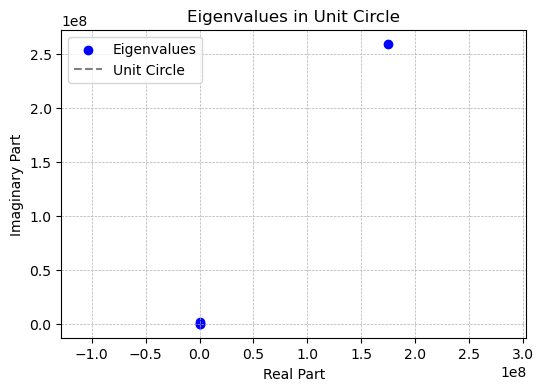

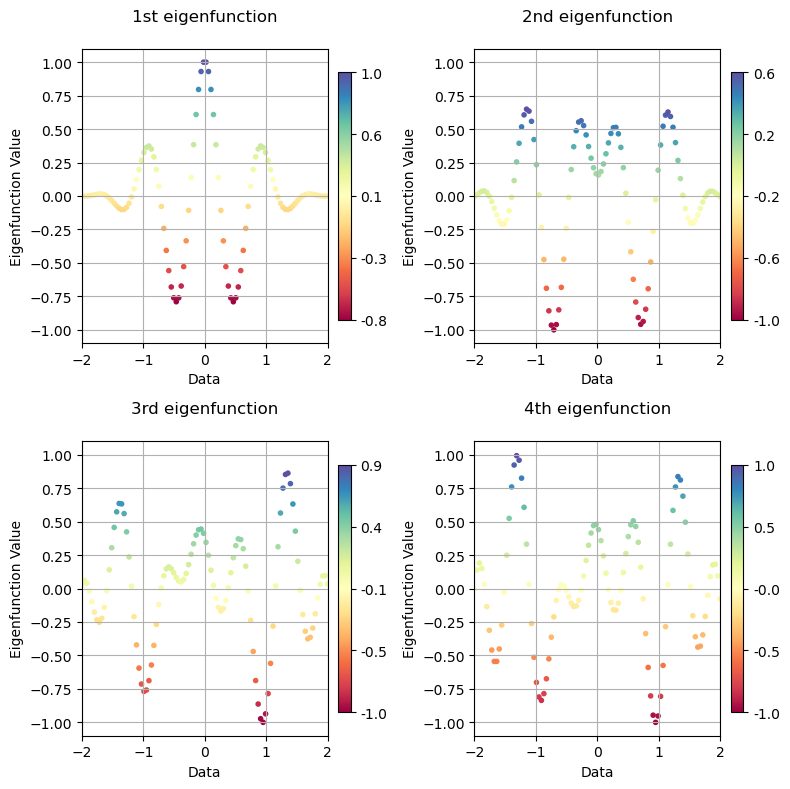

In [6]:
## EDMD
# ln_evalues = np.log(evalues[:4]) / lag_time
ln_evalues_EDMD_leading = (eigvals_EDMD[:4]-1) / delta_t

print(ln_evalues_EDMD_leading)

## Plot eigenvalues on unit circle
# Assuming evalues is a numpy array of complex numbers
real_parts = ln_evalues_EDMD_leading.real
imag_parts = ln_evalues_EDMD_leading.imag

# Create the plot
plt.figure(figsize=(6, 4))
plt.scatter(real_parts, imag_parts, color='blue', label='Eigenvalues')

# Draw a unit circle for reference
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), linestyle='--', color='grey', label='Unit Circle')

plt.title('Eigenvalues in Unit Circle')
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.axis('equal')  # Ensure the aspect ratio is equal to make the unit circle round
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()


## Plot eigenfunctions
# Get the real part of eigenfunctions and normalize them
phi = np.real(eigenfuns_EDMD)

# 归一化每个 eigenfunction，colorbar 只反映当前 eigenfunction 的数值分布
fig, axs = plt.subplots(2, 2, figsize=(8, 8))
titles = ['1st eigenfunction', '2nd eigenfunction', '3rd eigenfunction', '4th eigenfunction']
axs_flat = axs.flatten()

for i, (ax, title) in enumerate(zip(axs_flat, titles)):
    phi_i = np.real(eigenfuns_EDMD[:, i])
    phi_i = phi_i / np.max(np.abs(phi_i))  # 单独归一化
    vmin = np.min(phi_i)
    vmax = np.max(phi_i)
    cbar_ticks = np.linspace(vmin, vmax, 5)
    scatter = ax.scatter(X, phi_i, c=phi_i, cmap='Spectral', marker='.', vmin=vmin, vmax=vmax)
    ax.set_title(title, pad=20)
    ax.set_xlabel('Data')
    ax.set_ylabel('Eigenfunction Value')
    ax.set_xlim(-2, 2)
    ax.set_ylim(-1.1, 1.1)
    cbar = fig.colorbar(scatter, ax=ax, orientation='vertical', fraction=0.046, pad=0.04, ticks=cbar_ticks)
    cbar.set_ticklabels([f"{tick:.1f}" for tick in cbar_ticks])
    ax.grid()
plt.tight_layout()
plt.show()

[ 0.        +0.00000000e+00j  0.        +0.00000000e+00j
 -1.87487857+1.88152905e+01j -1.        +2.98480858e-13j]


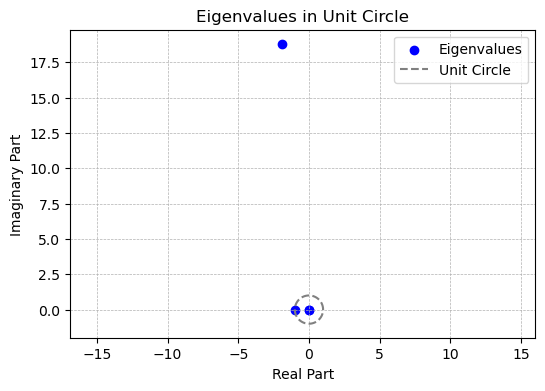

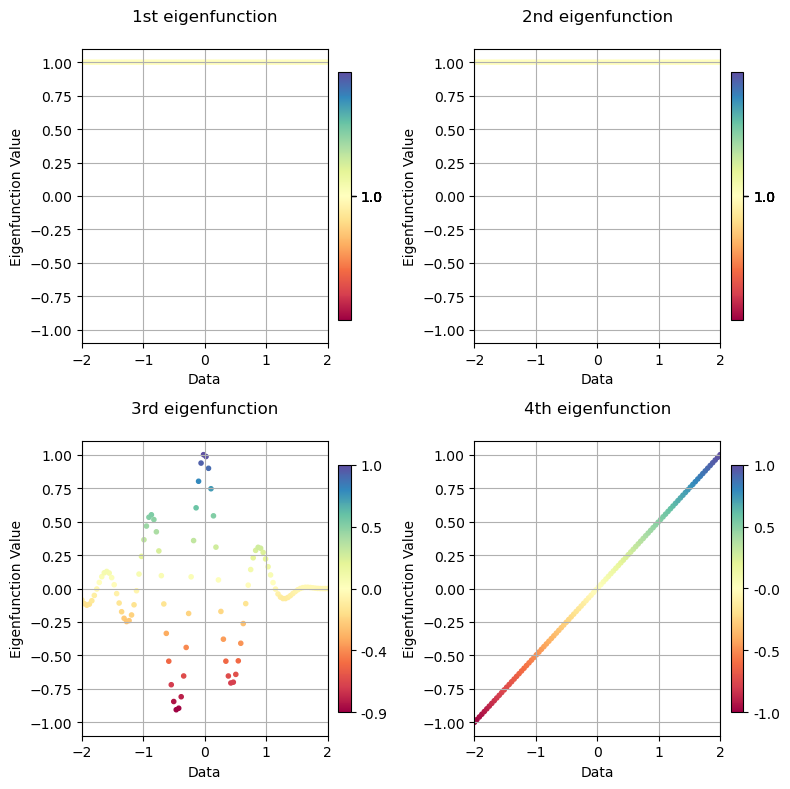

In [7]:
## SDMD
# ln_evalues = np.log(evalues[:4]) / lag_time
ln_evalues_SDMD_leading = (eigvals_SDMD[:4]-1) / delta_t

print(ln_evalues_SDMD_leading)

## Plot eigenvalues on unit circle
# Assuming evalues is a numpy array of complex numbers
real_parts = ln_evalues_SDMD_leading.real
imag_parts = ln_evalues_SDMD_leading.imag

# Create the plot
plt.figure(figsize=(6, 4))
plt.scatter(real_parts, imag_parts, color='blue', label='Eigenvalues')

# Draw a unit circle for reference
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), linestyle='--', color='grey', label='Unit Circle')

plt.title('Eigenvalues in Unit Circle')
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.axis('equal')  # Ensure the aspect ratio is equal to make the unit circle round
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()


## Plot eigenfunctions
# Get the real part of eigenfunctions and normalize them
phi = np.real(eigenfuns_SDMD)

# 归一化每个 eigenfunction，colorbar 只反映当前 eigenfunction 的数值分布
fig, axs = plt.subplots(2, 2, figsize=(8, 8))
titles = ['1st eigenfunction', '2nd eigenfunction', '3rd eigenfunction', '4th eigenfunction']
axs_flat = axs.flatten()

for i, (ax, title) in enumerate(zip(axs_flat, titles)):
    phi_i = np.real(eigenfuns_SDMD[:, i])
    phi_i = phi_i / np.max(np.abs(phi_i))  # 单独归一化
    vmin = np.min(phi_i)
    vmax = np.max(phi_i)
    cbar_ticks = np.linspace(vmin, vmax, 5)
    scatter = ax.scatter(X, phi_i, c=phi_i, cmap='Spectral', marker='.', vmin=vmin, vmax=vmax)
    ax.set_title(title, pad=20)
    ax.set_xlabel('Data')
    ax.set_ylabel('Eigenfunction Value')
    ax.set_xlim(-2, 2)
    ax.set_ylim(-1.1, 1.1)
    cbar = fig.colorbar(scatter, ax=ax, orientation='vertical', fraction=0.046, pad=0.04, ticks=cbar_ticks)
    cbar.set_ticklabels([f"{tick:.1f}" for tick in cbar_ticks])
    ax.grid()
plt.tight_layout()
plt.show()

[ 0.        +0.00000000e+00j  0.        +0.00000000e+00j
 -1.87487857+1.88152905e+01j -1.        +3.68224928e-13j]


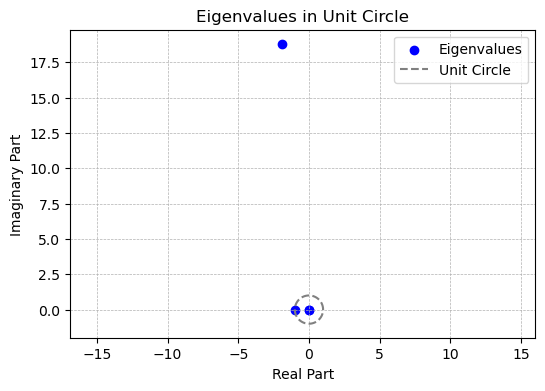

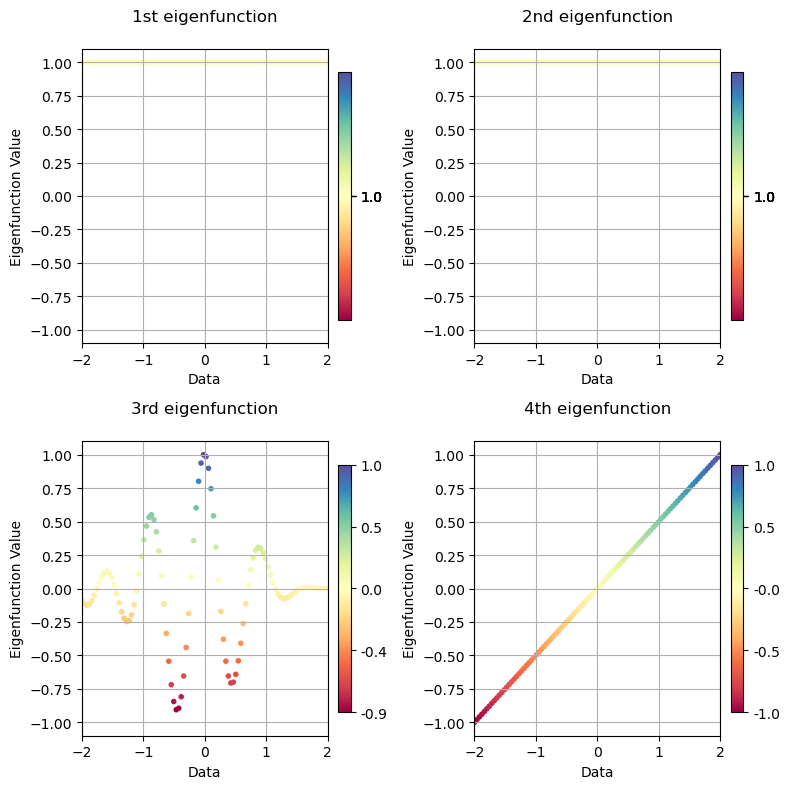

In [8]:
## gEDMD
# ln_evalues = np.log(evalues[:4]) / lag_time
eigvals_gEDMD_leading = eigvals_gEDMD[:4]

print(eigvals_gEDMD_leading)

## Plot eigenvalues on unit circle
# Assuming evalues is a numpy array of complex numbers
real_parts = eigvals_gEDMD_leading.real
imag_parts = eigvals_gEDMD_leading.imag

# Create the plot
plt.figure(figsize=(6, 4))
plt.scatter(real_parts, imag_parts, color='blue', label='Eigenvalues')

# Draw a unit circle for reference
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), linestyle='--', color='grey', label='Unit Circle')

plt.title('Eigenvalues in Unit Circle')
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.axis('equal')  # Ensure the aspect ratio is equal to make the unit circle round
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()


## Plot eigenfunctions
# Get the real part of eigenfunctions and normalize them
phi = np.real(eigenfuns_gEDMD)

# 归一化每个 eigenfunction，colorbar 只反映当前 eigenfunction 的数值分布
fig, axs = plt.subplots(2, 2, figsize=(8, 8))
titles = ['1st eigenfunction', '2nd eigenfunction', '3rd eigenfunction', '4th eigenfunction']
axs_flat = axs.flatten()

for i, (ax, title) in enumerate(zip(axs_flat, titles)):
    phi_i = np.real(eigenfuns_gEDMD[:, i])
    phi_i = phi_i / np.max(np.abs(phi_i))  # 单独归一化
    vmin = np.min(phi_i)
    vmax = np.max(phi_i)
    cbar_ticks = np.linspace(vmin, vmax, 5)
    scatter = ax.scatter(X, phi_i, c=phi_i, cmap='Spectral', marker='.', vmin=vmin, vmax=vmax)
    ax.set_title(title, pad=20)
    ax.set_xlabel('Data')
    ax.set_ylabel('Eigenfunction Value')
    ax.set_xlim(-2, 2)
    ax.set_ylim(-1.1, 1.1)
    cbar = fig.colorbar(scatter, ax=ax, orientation='vertical', fraction=0.046, pad=0.04, ticks=cbar_ticks)
    cbar.set_ticklabels([f"{tick:.1f}" for tick in cbar_ticks])
    ax.grid()
plt.tight_layout()
plt.show()

In [9]:
# 显示前几个数据点的前几个 eigenfunction 数值
print("efuns (first 5 points, first 4 eigenfunctions):")
print(eigenfuns_gEDMD[:5, :4])

efuns (first 5 points, first 4 eigenfunctions):
[[ 1.        +0.00000000e+00j  1.        +0.00000000e+00j
  -0.18782639+2.23548790e-01j -2.        -6.19999653e-12j]
 [ 1.        +0.00000000e+00j  1.        +0.00000000e+00j
  -0.2505791 +1.33238163e-01j -1.95959596-7.81417959e-12j]
 [ 1.        +0.00000000e+00j  1.        +0.00000000e+00j
  -0.27499835+2.71229098e-02j -1.91919192-8.99236417e-12j]
 [ 1.        +0.00000000e+00j  1.        +0.00000000e+00j
  -0.25780196-7.96185605e-02j -1.87878788-9.64738692e-12j]
 [ 1.        +0.00000000e+00j  1.        +0.00000000e+00j
  -0.20145392-1.71460323e-01j -1.83838384-9.71529910e-12j]]
